In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean

In [2]:
from OceanDataStore import OceanDataCatalog

In [17]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [19]:
catalog.search(collection='noc-npd-era5')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/U1y
              Title: eORCA1 ERA5v1 NPD U1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at U-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/V1y
              Title: eORCA1 ERA5v1 NPD V1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global oc

In [5]:
catalog.Items[]

<Item id=noc-npd-era5/npd-eorca1-era5v1/gn/S1y>

In [23]:
ds1 = catalog.open_dataset(id=catalog.Items[74].id)

ds1

<xarray.Dataset> Size: 74GB
Dimensions:        (y: 3605, x: 4320, nav_lev: 75)
Coordinates:
  * y              (y) int64 29kB 0 1 2 3 4 5 ... 3599 3600 3601 3602 3603 3604
  * x              (x) int64 35kB 0 1 2 3 4 5 ... 4314 4315 4316 4317 4318 4319
  * nav_lev        (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
Data variables: (12/57)
    bathy_metry    (y, x) float64 125MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    bottom_level   (y, x) int32 62MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    e1f            (y, x) float64 125MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    e1u            (y, x) float64 125MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    e2f            (y, x) float64 125MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    e2u            (y, x) float64 125MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    ...             ...
    umask          (nav_lev, y, x) bool 1GB dask.array<chunksize=(25, 721, 540), meta=np.ndarray>
    umaskutil      (y, x) bool 16MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    vmask          (nav_lev, y, x) bool 1GB dask.array<chunksize=(25, 721, 540), meta=np.ndarray>
    vmaskutil      (y, x) bool 16MB dask.array<chunksize=(721, 540), meta=np.ndarray>
    wmask          (nav_lev, y, x) bool 1GB dask.array<chunksize=(25, 721, 540), meta=np.ndarray>
    wmaskutil      (y, x) bool 16MB dask.array<chunksize=(721, 540), meta=np.ndarray>
Attributes:
    file_name:  domain_cfg.nc
    TimeStamp:  20/01/2022 11:38:23 +0000
    history:    Thu Jan 20 12:13:27 2022: ncap2 -swhere(mask_opensea<1) botto...
    NCO:        netCDF Operators version 4.7.6 (Homepage = http://nco.sf.net,...

In [7]:
## Checking NaNs 

# Boolean mask of NaNs
nan_mask = ds1["tos_con"].isnull()

# Count NaNs over time at each grid cell
nan_count = nan_mask.sum(dim="time_counter")

# Total number of timesteps
nt = ds1.sizes["time_counter"]

# Grid cells where:
#   0 < nan_count < nt
partial_nan_mask = (nan_count > 0) & (nan_count < nt)

# Count how many such grid cells exist
n_partial = partial_nan_mask.sum().compute().item()


print(f"Number of grid cells with partial NaNs: {n_partial}")

if n_partial > 0:
    print("There ARE grid cells with NaNs at some, but not all, timesteps.")
else:
    print("All grid cells are either completely NaN or completely valid.")

Number of grid cells with partial NaNs: 0
All grid cells are either completely NaN or completely valid.


In [16]:
ds1['so_abs']

<xarray.DataArray 'so_abs' (time_counter: 35, deptht: 75, y: 331, x: 360)> Size: 1GB
dask.array<getitem, shape=(35, 75, 331, 360), dtype=float32, chunksize=(1, 25, 331, 360), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 280B 1990-07-02T12:00:00 ......
  * deptht         (deptht) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
    nav_lon        (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lat        (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    time_centered  (time_counter) datetime64[ns] 280B dask.array<chunksize=(1,), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    standard_name:       sea_water_absolute_salinity
    long_name:           sea_water_absolute_salinity
    units:               g/kg
    online_operation:    average
    interval_operation:  1 yr
    interval_write:      1 yr
    cell_methods:        time: mean

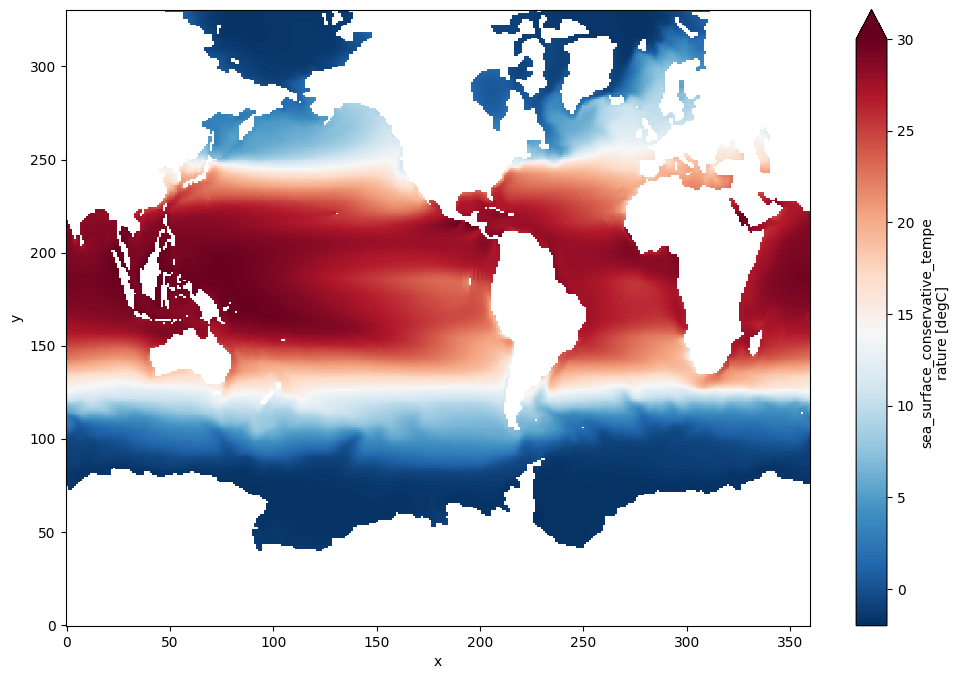

In [9]:
## Plotting with default method 

ds1['tos_con'].mean(dim='time_counter').plot(cmap='RdBu_r', figsize = (12,8), vmin = -2, vmax = 30)


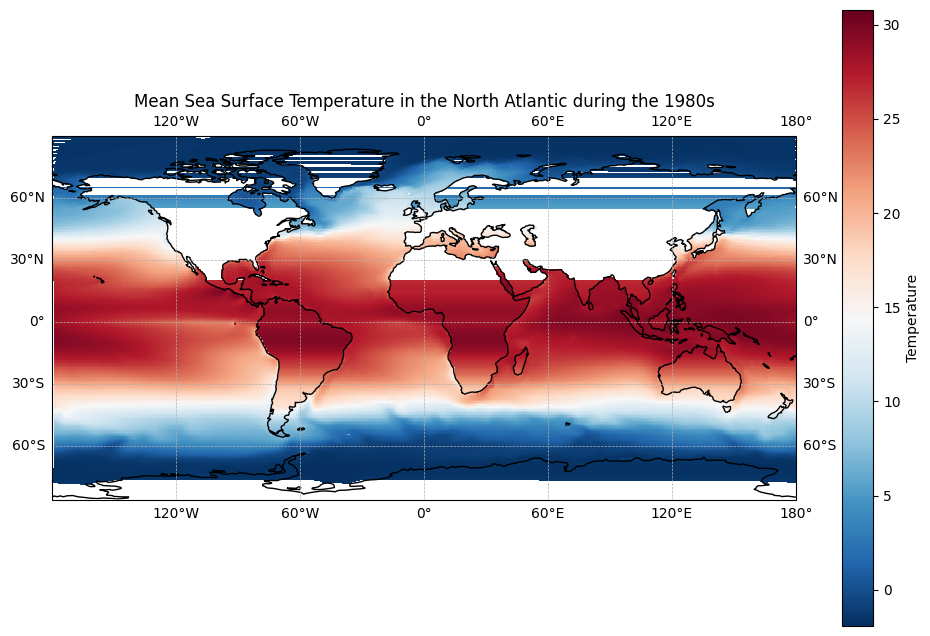

In [10]:
## Plotting North Atlantic using cartopy 

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

data = ds1['tos_con'].mean(dim='time_counter')
im = ax.pcolormesh(ds1['nav_lon'],  ds1['nav_lat'], data, cmap='RdBu_r', transform=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
ax.set_title('Mean Sea Surface Temperature in the North Atlantic during the 1980s')

plt.colorbar(im, ax=ax, label='Temperature')
plt.show()

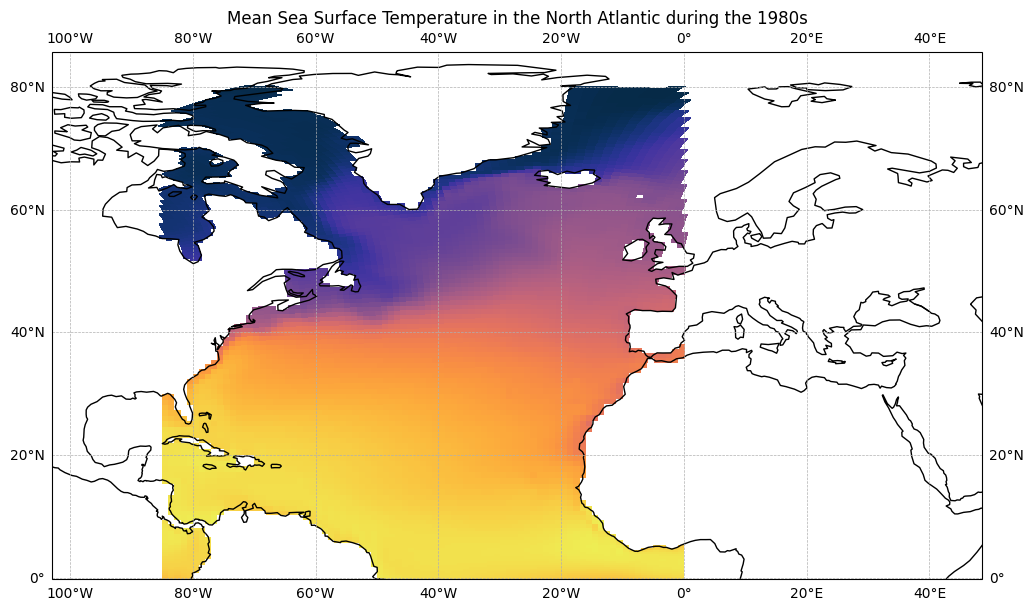

In [19]:
ds2 = catalog.open_dataset(id=catalog.Items[0].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12',
                          bbox = (-85.0, 0.0, 0.0, 80.0))

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
data = ds2['tos_con'].mean(dim='time_counter')
im = ax.pcolormesh(ds2['nav_lon'],  ds2['nav_lat'], data, cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree(), vmin = -3, vmax = 30)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
ax.set_title('Mean Sea Surface Temperature in the North Atlantic during the 1980s')
#ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())

plt.show()

In [20]:
ds2

<xarray.Dataset> Size: 3GB
Dimensions:                (deptht: 75, axis_nbounds: 2, y: 135, x: 85,
                            time_counter: 35)
Coordinates:
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
  * time_counter           (time_counter) datetime64[ns] 280B 1990-07-02T12:0...
    nav_lon                (y, x) float64 92kB -84.5 -83.5 -82.5 ... 45.74 46.87
    nav_lat                (y, x) float64 92kB 0.0 0.0 0.0 ... 80.05 79.65 79.25
    time_centered          (time_counter) datetime64[ns] 280B dask.array<chunksize=(1,), meta=np.ndarray>
Dimensions without coordinates: axis_nbounds, y, x
Data variables: (12/74)
    deptht_bounds          (deptht, axis_nbounds, y, x) float32 7MB dask.array<chunksize=(25, 2, 135, 85), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 2MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 2MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    friver                 (time_counter, y, x) float32 2MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    fsitherm               (time_counter, y, x) float32 2MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    hfds                   (time_counter, y, x) float32 2MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    ...                     ...
    vohflisf               (time_counter, deptht, y, x) float32 120MB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    ttrd_bbl_li            (time_counter, deptht, y, x) float32 120MB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 120MB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 2MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 2MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    ttrd_qns_li            (time_counter, y, x) float32 2MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>

In [16]:
print("data.shape:", data.shape)
print("nav_lon.shape:", ds1['nav_lon'].shape)
print("nav_lat.shape:", ds1['nav_lat'].shape)
print("lon min/max:", ds1['nav_lon'].min().values, ds1['nav_lon'].max().values)
print("lat min/max:", ds1['nav_lat'].min().values, ds1['nav_lat'].max().values)

data.shape: (331, 360)
nav_lon.shape: (331, 360)
nav_lat.shape: (331, 360)
lon min/max: -179.99653278676575 179.99031297181477
lat min/max: -85.78874492732504 89.7417689202141


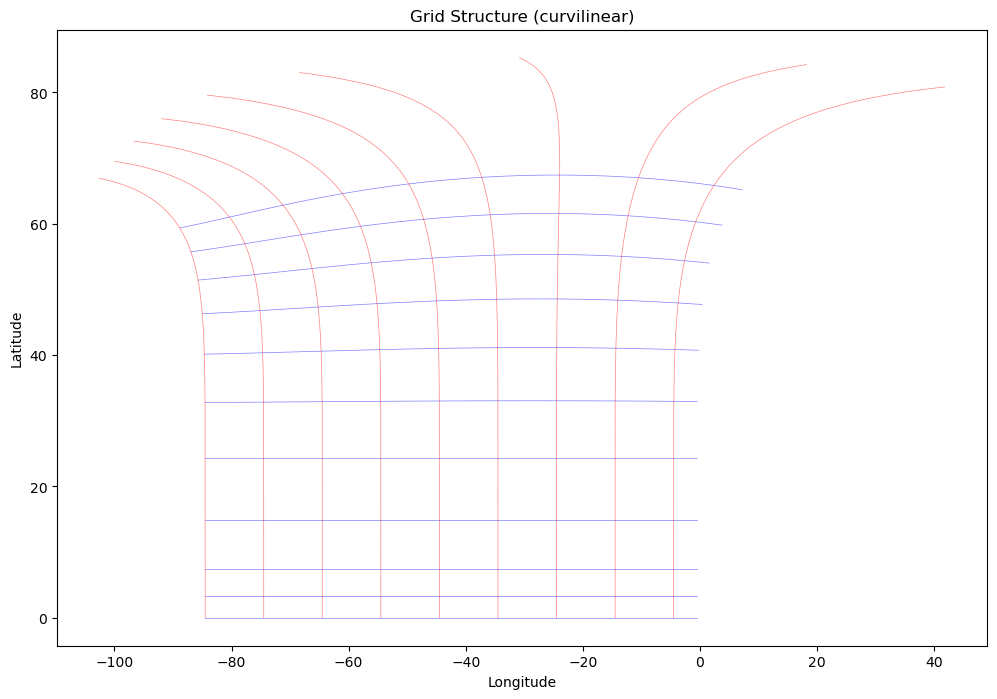

In [15]:
#### What does a Curvilinear grid look like?

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

for i in range(0, 106, 10):
    ax.plot(ds2['nav_lon'][i, :], ds2['nav_lat'][i, :], 'b-', alpha=0.5, linewidth=0.5)
    
for j in range(0, 90, 10):
    ax.plot(ds2['nav_lon'][:, j], ds2['nav_lat'][:, j], 'r-', alpha=0.5, linewidth=0.5)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Grid Structure (curvilinear)')
plt.show()